In [1]:
from os import read

import pandas as pd
import numpy as np

# Copy your dataframe
df_meta = pd.read_csv("SC_subjects.csv")  # Replace with your actual file path

# ----------------------------
# Convert LightsOff to minutes
# ----------------------------
def time_to_minutes_adjusted(t):
    h, m = map(int, t.split(":"))
    minutes = h * 60 + m
    if minutes < 720:  # treat after midnight as next day
        minutes += 24 * 60
    return minutes

df_meta["LightsOff_min"] = df_meta["LightsOff"].apply(time_to_minutes_adjusted)

# ----------------------------
# Aggregate to subject level
# ----------------------------
df_subject = df_meta.groupby("subject").agg({
    "age": "first",
    "sex (F=1)": "first",
    "LightsOff_min": "mean"
}).reset_index()

df_subject.head()

,subject,age,sex (F=1),LightsOff_min
0,0,33,1,1397.5
1,1,33,1,1349.5
2,2,26,1,1373.5
3,3,26,1,1453.0
4,4,34,1,1403.5


In [2]:
from sklearn.preprocessing import StandardScaler

features = ["age", "sex (F=1)", "LightsOff_min"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_subject[features])

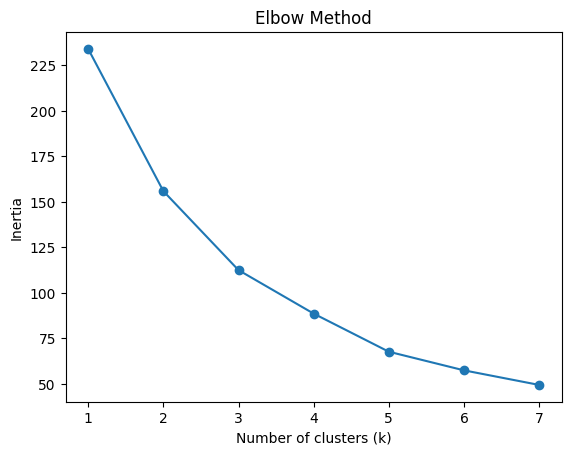

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

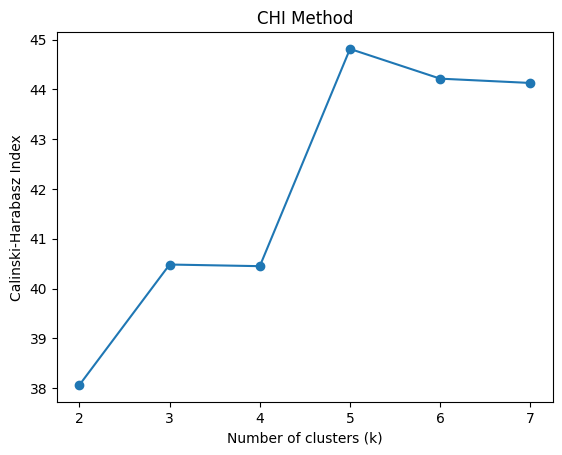

In [4]:
from sklearn.metrics import calinski_harabasz_score

chi_scores = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    chi = calinski_harabasz_score(X_scaled, labels)
    chi_scores.append(chi)

# Plot
plt.figure()
plt.plot(K_range, chi_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Calinski-Harabasz Index")
plt.title("CHI Method")
plt.show()

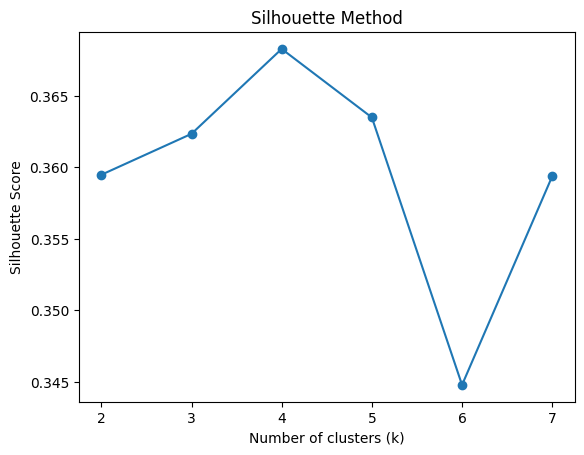

In [5]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.figure()
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

In [26]:
# Choose k (example: 5)
k = 5

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_subject["cluster"] = kmeans.fit_predict(X_scaled)

df_subject

,subject,age,sex (F=1),LightsOff_min,cluster
0,0,33,1,1397.5,0
1,1,33,1,1349.5,0
2,2,26,1,1373.5,0
3,3,26,1,1453.0,0
4,4,34,1,1403.5,0
...,...,...,...,...,...
73,76,90,2,1468.5,4
74,77,85,2,1426.5,4
75,80,54,1,1391.5,0
76,81,57,1,1318.0,3


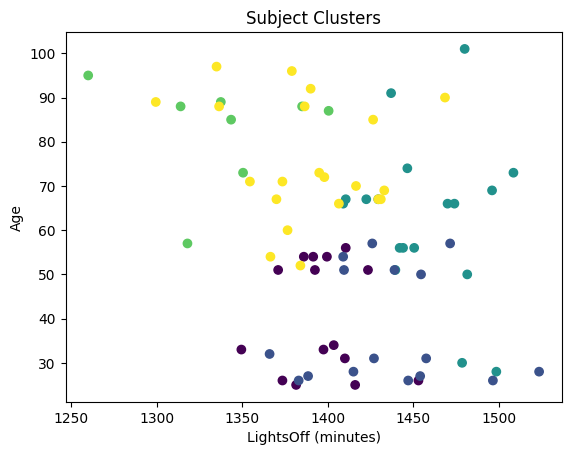

In [27]:
plt.figure()

plt.scatter(
    df_subject["LightsOff_min"],
    df_subject["age"],
    c=df_subject["cluster"]
)

plt.xlabel("LightsOff (minutes)")
plt.ylabel("Age")
plt.title("Subject Clusters")

plt.show()

C:\Users\Thiwanka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
C:\Users\Thiwanka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
C:\Users\Thiwanka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
C:\Users\Thiwanka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
C:\Users\Thiwanka\AppData\Lo

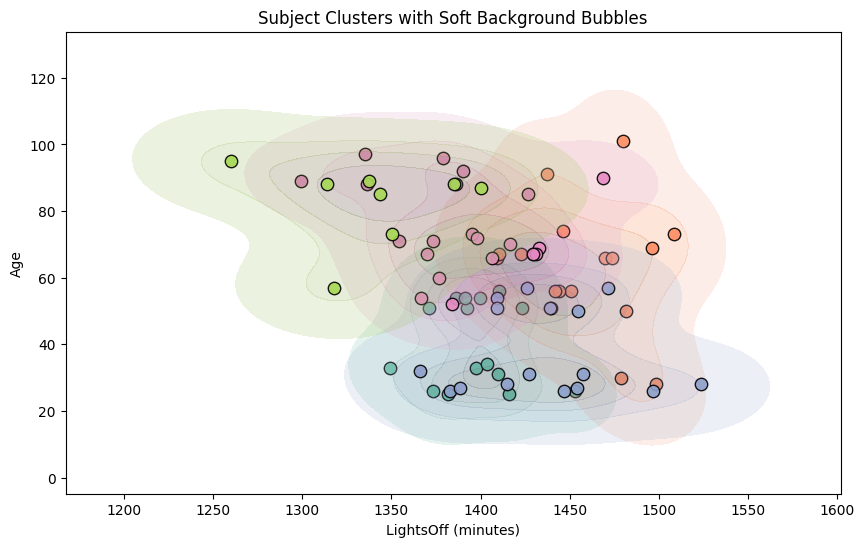

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10,6))

# Colors
colors = sns.color_palette("Set2", df_subject["cluster"].nunique())

for cluster_id, color in zip(df_subject["cluster"].unique(), colors):
    cluster_points = df_subject[df_subject["cluster"] == cluster_id][["LightsOff_min", "age"]]
    
    # Soft background using 2D KDE contour
    sns.kdeplot(
        x=cluster_points["LightsOff_min"],
        y=cluster_points["age"],
        levels=5,        # Number of contour levels
        fill=True,
        alpha=0.2,       # Transparency of the bubble
        color=color,
        linewidths=0
    )
    
    # Scatter points on top
    plt.scatter(
        cluster_points["LightsOff_min"],
        cluster_points["age"],
        color=color,
        s=80,
        edgecolor='k',
        alpha=0.9
    )

plt.xlabel("LightsOff (minutes)")
plt.ylabel("Age")
plt.title("Subject Clusters with Soft Background Bubbles")
plt.show()

In [28]:
cluster_summary = df_subject.groupby("cluster").mean()
cluster_summary

,subject,age,sex (F=1),LightsOff_min
cluster,,,,
0,17.066667,40.266667,1.0,1397.266667
1,21.687500,37.625000,2.0,1435.468750
2,39.888889,63.000000,1.0,1456.555556
3,64.000000,82.750000,1.0,1338.625000
4,58.904762,75.428571,2.0,1388.380952


### Cluster-wise interpretation

🔹 Cluster 0

Cluster 0 consists of younger adults (mean age ≈ 40) who tend to go to sleep relatively late (≈ 11:17 PM). The group is entirely composed of females. This cluster represents a mid-age, late-sleeping female group, suggesting a tendency toward delayed sleep onset in this demographic.

🔹 Cluster 1

Cluster 1 includes slightly younger individuals (mean age ≈ 38) with the latest sleep onset times (≈ 11:55 PM) among all clusters. This group is predominantly male. This cluster reflects a late-sleeping male group, potentially indicating stronger evening-type behavior (night owls).

🔹 Cluster 2

Cluster 2 represents older adults (mean age ≈ 63) with very late sleep onset (≈ 12:16 AM). The group is entirely female. This suggests a late-sleeping older female group, which is somewhat unexpected, as older individuals are often associated with earlier sleep timing.

🔹 Cluster 3

Cluster 3 consists of the oldest individuals (mean age ≈ 83) with the earliest sleep onset (≈ 10:18 PM). This group is entirely female. This cluster aligns well with known sleep patterns, representing an early-sleeping elderly group, consistent with advanced circadian rhythms in aging.

🔹 Cluster 4

Cluster 4 includes older adults (mean age ≈ 75) with moderately early sleep onset (≈ 11:08 PM). The group is predominantly male. This cluster reflects an older male group with earlier sleep tendencies, though not as early as Cluster 3.

In [29]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

features = ["age", "sex (F=1)", "LightsOff_min"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_subject[features])

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_subject["cluster"] = kmeans.fit_predict(X_scaled)

In [30]:
representatives = []

for i in range(5):
    cluster_points = X_scaled[df_subject["cluster"] == i]
    cluster_indices = df_subject[df_subject["cluster"] == i].index
    
    centroid = kmeans.cluster_centers_[i]
    
    # Compute distance to centroid
    distances = np.linalg.norm(cluster_points - centroid, axis=1)
    
    # Find closest subject
    closest_idx = cluster_indices[np.argmin(distances)]
    
    representatives.append(df_subject.loc[closest_idx])

# Convert to DataFrame
rep_df = pd.DataFrame(representatives)

rep_df

,subject,age,sex (F=1),LightsOff_min,cluster
4,4.0,34.0,1.0,1403.5,0.0
15,15.0,31.0,2.0,1427.0,1.0
44,45.0,66.0,1.0,1470.0,2.0
63,64.0,85.0,1.0,1343.5,3.0
53,54.0,73.0,2.0,1395.0,4.0


In [32]:
from sklearn.preprocessing import StandardScaler

features = ["age", "sex (F=1)", "LightsOff_min"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_subject[features])

In [33]:
from scipy.cluster.hierarchy import linkage

Z = linkage(X_scaled, method="ward")

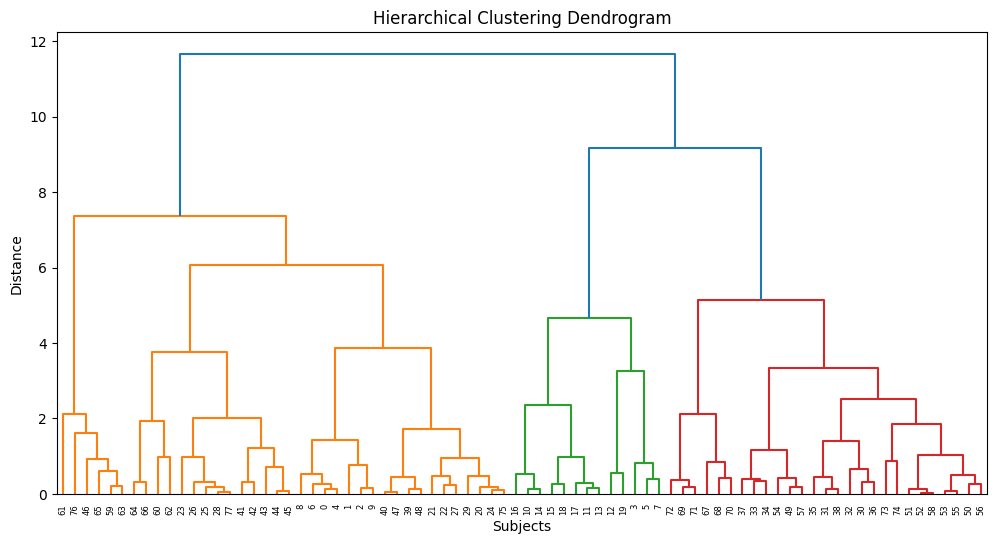

In [34]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Subjects")
plt.ylabel("Distance")
plt.show()